# Paradigma Orientado a Objetos

Una clase --> la fabrica de objetos (instancias)

$x \in \mathbb{Clase}$

x : Propiedades (atributos)
x : Funciones asociadas (Métodos)

Originalmente se derivaron /struct/ (estructura de datos)

Estructura general en Python



## Ejemplo concreto: Caminante Aleatorio

### Abstracción:
Un caminante (instancia) que lanza una moneda en el tiempo $t_0$, si la moneda cae águila entonces avanza para adelante, si cae sol, avanza atrás. 




In [37]:
import numpy as np

In [38]:
np.random.binomial(1,0.5)

0

In [39]:
class Caminante:
    """
    Clase que implementa un Caminante Aleatorio muy sencillo
    """
    num_caminantes = 1
    num_habitantes = 300

    def __init__(self,nombre="Anónimo",sezgo=0.5):
        """
        Constructor de instancias
        Parámetros:
            sezgo : probabilidad de éxito en un ensayo (Bernoulli)
        """
        self.posicion = 0.0
        self.nombre = nombre
        self.recorrido = []
        self.sezgo=sezgo


    @staticmethod
    def calculo_de_distancia(pos1, pos2):
        """
        Método estático es independiente del estado de las instancias o de la clase
        """
        return abs(pos1,pos2)


    @property ## Tratar método como atributo
    def promedio_caminata(self):
        n = len(self.recorrido)
        return sum(self.recorrido) / n
    
    def get_posicion(self):
        return self.posicion

    def set_posicion(self,nueva_posicion):
        self.posicion = nueva_posicion

        
    def paso(self):
        """
        Dar un paso dependiendo de un número aleatorio
        """
        moneda = np.random.binomial(1,self.sezgo)
        # 0 : decimos es águila
        # 1 : decimos es sol
        if moneda == 0: # águila
            self.posicion += 1
            #print("Águila")
        else: 
            self.posicion -= 1
            #print("Sol")
        self.recorrido.append(self.posicion)

    def caminata(self, num_pasos):
        """
        Recorrido aleatorio dado un número de pasos.
        """
        for i in range(num_pasos):
            self.paso()
        print(f"Caminé {num_pasos} pasos")    


    def __eq__(self,otro):
        """
        Sobrecarga (override) del operador ==
        
        """
        if otro.nombre == self.nombre:
            return True
        else:
            return False


    # definir operadores algebraicos
    def __add__(self,otro):
        """
        Sobrecarga del operador suma
        """
        c = Caminante()
        c.posicion = self.posicion + otro.posicion
        return c
        
        
    def __repr__(self):
        cadena = f"<Caminante: {self.nombre}: Posición {self.posicion}> "
        return cadena

## Crear instancias del caminante

In [40]:
caminante_1 = Caminante(nombre="fulanito")

In [41]:
print(caminante_1)

<Caminante: fulanito: Posición 0.0> 


In [42]:
for x in range(10000):
    caminante_1.paso()

In [43]:
caminante_1.posicion

186.0

In [44]:
caminante_1.recorrido

[1.0,
 2.0,
 1.0,
 0.0,
 -1.0,
 0.0,
 1.0,
 0.0,
 -1.0,
 0.0,
 -1.0,
 0.0,
 -1.0,
 0.0,
 1.0,
 2.0,
 3.0,
 2.0,
 1.0,
 0.0,
 -1.0,
 -2.0,
 -3.0,
 -2.0,
 -3.0,
 -2.0,
 -1.0,
 0.0,
 -1.0,
 -2.0,
 -1.0,
 0.0,
 1.0,
 0.0,
 -1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 -1.0,
 -2.0,
 -1.0,
 0.0,
 -1.0,
 0.0,
 1.0,
 2.0,
 3.0,
 2.0,
 1.0,
 0.0,
 1.0,
 2.0,
 1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 4.0,
 3.0,
 4.0,
 5.0,
 4.0,
 5.0,
 4.0,
 5.0,
 6.0,
 7.0,
 6.0,
 5.0,
 4.0,
 5.0,
 6.0,
 5.0,
 6.0,
 7.0,
 8.0,
 7.0,
 6.0,
 5.0,
 4.0,
 5.0,
 6.0,
 7.0,
 6.0,
 7.0,
 6.0,
 5.0,
 6.0,
 5.0,
 4.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 6.0,
 7.0,
 8.0,
 7.0,
 8.0,
 9.0,
 8.0,
 7.0,
 6.0,
 5.0,
 4.0,
 5.0,
 4.0,
 3.0,
 2.0,
 3.0,
 2.0,
 1.0,
 2.0,
 3.0,
 4.0,
 3.0,
 2.0,
 1.0,
 0.0,
 -1.0,
 -2.0,
 -3.0,
 -2.0,
 -3.0,
 -2.0,
 -3.0,
 -4.0,
 -5.0,
 -4.0,
 -5.0,
 -6.0,
 -7.0,
 -6.0,
 -7.0,
 -6.0,
 -5.0,
 -6.0,
 -7.0,
 -8.0,
 -7.0,
 -6.0,
 -7.0,
 -6.0,
 -5.0,
 -4.0,
 -3.0,
 -2.0,
 -3.0,
 -2.0,
 -3.0,
 -4.0,
 -5.0,
 -4.0,

In [45]:
caminante_1.promedio_caminata

46.573

### Otra instancia

In [46]:
caminante_2 = Caminante(nombre="fulanita")
for i in range(10000):
    caminante_2.paso()

In [47]:
caminante_2.posicion

236.0

In [48]:
caminante_1.posicion 

186.0

## Montón de caminantes

In [49]:
num_habitantes = 300 #num de caminantes
población = []
for i in range(num_habitantes):
    población.append(Caminante(nombre=i))
    

In [50]:
población

[<Caminante: 0: Posición 0.0> ,
 <Caminante: 1: Posición 0.0> ,
 <Caminante: 2: Posición 0.0> ,
 <Caminante: 3: Posición 0.0> ,
 <Caminante: 4: Posición 0.0> ,
 <Caminante: 5: Posición 0.0> ,
 <Caminante: 6: Posición 0.0> ,
 <Caminante: 7: Posición 0.0> ,
 <Caminante: 8: Posición 0.0> ,
 <Caminante: 9: Posición 0.0> ,
 <Caminante: 10: Posición 0.0> ,
 <Caminante: 11: Posición 0.0> ,
 <Caminante: 12: Posición 0.0> ,
 <Caminante: 13: Posición 0.0> ,
 <Caminante: 14: Posición 0.0> ,
 <Caminante: 15: Posición 0.0> ,
 <Caminante: 16: Posición 0.0> ,
 <Caminante: 17: Posición 0.0> ,
 <Caminante: 18: Posición 0.0> ,
 <Caminante: 19: Posición 0.0> ,
 <Caminante: 20: Posición 0.0> ,
 <Caminante: 21: Posición 0.0> ,
 <Caminante: 22: Posición 0.0> ,
 <Caminante: 23: Posición 0.0> ,
 <Caminante: 24: Posición 0.0> ,
 <Caminante: 25: Posición 0.0> ,
 <Caminante: 26: Posición 0.0> ,
 <Caminante: 27: Posición 0.0> ,
 <Caminante: 28: Posición 0.0> ,
 <Caminante: 29: Posición 0.0> ,
 <Caminante: 30: Pos

### Comienza el recorrido de todos

In [51]:
num_pasos = 1000
for caminante in población:
    caminante.caminata(num_pasos)

Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 100

In [52]:
población

[<Caminante: 0: Posición -2.0> ,
 <Caminante: 1: Posición -2.0> ,
 <Caminante: 2: Posición -2.0> ,
 <Caminante: 3: Posición -2.0> ,
 <Caminante: 4: Posición -74.0> ,
 <Caminante: 5: Posición -4.0> ,
 <Caminante: 6: Posición 8.0> ,
 <Caminante: 7: Posición -6.0> ,
 <Caminante: 8: Posición 26.0> ,
 <Caminante: 9: Posición -40.0> ,
 <Caminante: 10: Posición -60.0> ,
 <Caminante: 11: Posición -50.0> ,
 <Caminante: 12: Posición 0.0> ,
 <Caminante: 13: Posición 52.0> ,
 <Caminante: 14: Posición 20.0> ,
 <Caminante: 15: Posición -38.0> ,
 <Caminante: 16: Posición -12.0> ,
 <Caminante: 17: Posición 22.0> ,
 <Caminante: 18: Posición -4.0> ,
 <Caminante: 19: Posición -6.0> ,
 <Caminante: 20: Posición 52.0> ,
 <Caminante: 21: Posición -48.0> ,
 <Caminante: 22: Posición 4.0> ,
 <Caminante: 23: Posición -4.0> ,
 <Caminante: 24: Posición 16.0> ,
 <Caminante: 25: Posición -54.0> ,
 <Caminante: 26: Posición 90.0> ,
 <Caminante: 27: Posición 28.0> ,
 <Caminante: 28: Posición -60.0> ,
 <Caminante: 29: P

In [53]:
import matplotlib.pyplot as plt

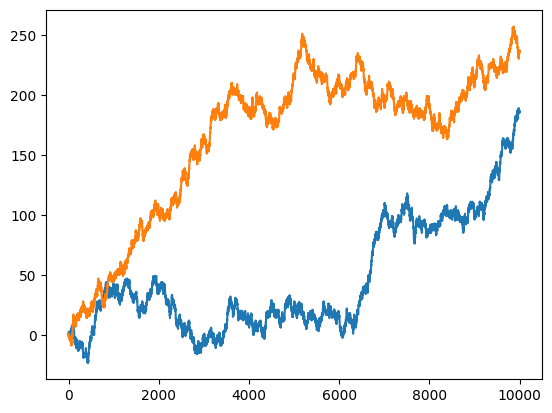

In [54]:
plt.plot(caminante_1.recorrido)
plt.plot(caminante_2.recorrido)

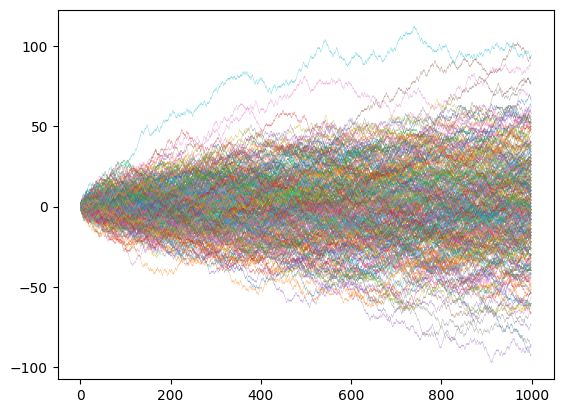

In [55]:
for caminante in población:
    plt.plot(caminante.recorrido,alpha=0.9,linewidth=0.2)

In [56]:
import pandas as pd

In [57]:
data = []
for cam in población:
    data.append(cam.recorrido)
    

In [58]:
data = pd.DataFrame(data)

### Promedio de caminantes al tiempo $i$

In [59]:
promedio_i = data.mean(axis=0)


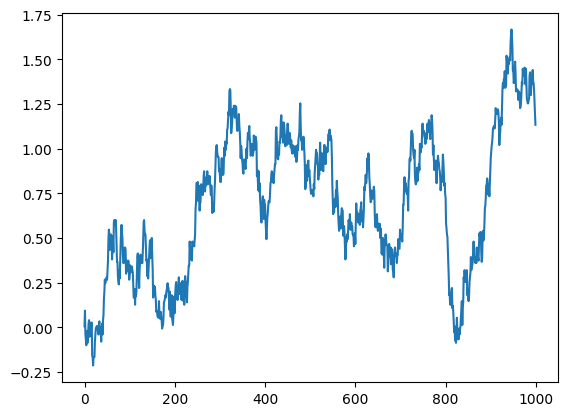

In [60]:
plt.plot(promedio_i)

### Promedio de todos los caminantes al final de la caminata

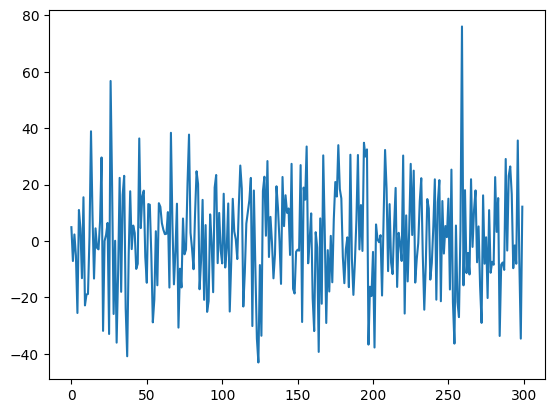

In [61]:
promedio_tot = data.mean(axis=1)
plt.plot(promedio_tot)

## Caminantes con sezgo

In [62]:
num_habitantes = 300 #num de caminantes
num_pasos = 1000

población = []
for i in range(num_habitantes):
    cam = Caminante(nombre=i,sezgo=0.499)
    cam.caminata(num_pasos)
    población.append(cam)

Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 1000 pasos
Caminé 100

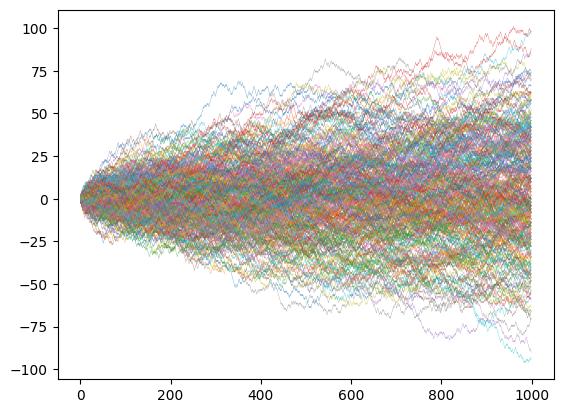

In [63]:
for caminante in población:
    plt.plot(caminante.recorrido,alpha=0.9,linewidth=0.2)

In [64]:
for c in población:
    print(c.num_caminantes)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [65]:
c1 = población[1]
c2 = población[2]

In [66]:
c1.nombre = "algo"
c2.nombre = "algo"

#### Sobrecarga del operador igual (invariante)

In [67]:
c1 == c2

True

In [68]:
c1.posicion

-18.0

In [69]:
c2.posicion

0.0

In [71]:
c3 = c1 + c2

In [72]:
c3

<Caminante: Anónimo: Posición -18.0> 

In [33]:
a = [2,3,4,4,4,6]

In [34]:
set(a)

{2, 3, 4, 6}